<a href="https://colab.research.google.com/github/fargonemaciel/nerd_dos_dados_codes/blob/main/FargonePrevendoPrecosDeVeiculos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Projeto 1 - Prevendo valores de veículos



### Definindo o Problema de Negócio
<p> Nosso objetivo é construir um modelo de Machile Learning que seja capaz de fazer previsões sobre o valor de venda de veículos, avaliando o melhor score apresentado.

In [75]:
# Install dependencies as needed:

!pip install kagglehub[pandas-datasets]

In [130]:
# Importing libraries

import kagglehub
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [77]:
# Configurações Gerais

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

In [78]:
# Data loading
file_path = "cardata.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "athirags/car-data",
  file_path
)

Using Colab cache for faster access to the 'car-data' dataset.


## EDA - Exploratory Data Analysis

In [79]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [80]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [81]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [82]:
df.shape

(301, 9)

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [84]:
df.isnull().sum().sort_values(ascending=False)

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [85]:
df.nunique().sort_values(ascending=False)

,0
Kms_Driven,206
Selling_Price,156
Present_Price,147
Car_Name,98
Year,16
Fuel_Type,3
Owner,3
Seller_Type,2
Transmission,2


In [86]:
for col in df.columns:
  print(f"\nAgrupamento da variável {col}")
  print(df[col].value_counts().head(10))


Agrupamento da variável Car_Name
Car_Name
city                         26
corolla altis                16
verna                        14
fortuner                     11
brio                         10
ciaz                          9
i20                           9
innova                        9
grand i10                     8
Royal Enfield Classic 350     7
Name: count, dtype: int64

Agrupamento da variável Year
Year
2015    61
2016    50
2014    38
2017    35
2013    33
2012    23
2011    19
2010    15
2008     7
2009     6
Name: count, dtype: int64

Agrupamento da variável Selling_Price
Selling_Price
0.45    8
0.60    8
4.50    7
5.25    7
4.75    6
0.20    6
5.50    5
4.00    5
1.05    5
0.25    5
Name: count, dtype: int64

Agrupamento da variável Present_Price
Present_Price
9.40     15
13.60    13
5.70      8
1.47      7
4.43      7
0.95      6
0.51      6
18.61     5
30.61     5
0.57      5
Name: count, dtype: int64

Agrupamento da variável Kms_Driven
Kms_Driven
15000    9
4500

In [87]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns
num_cols = df.select_dtypes(include=['int64', 'float']).columns
bool_cols = df.select_dtypes(include=['bool']).columns
date_cols = df.select_dtypes(include=['datetime64']).columns

In [88]:
list(num_cols)

['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner']

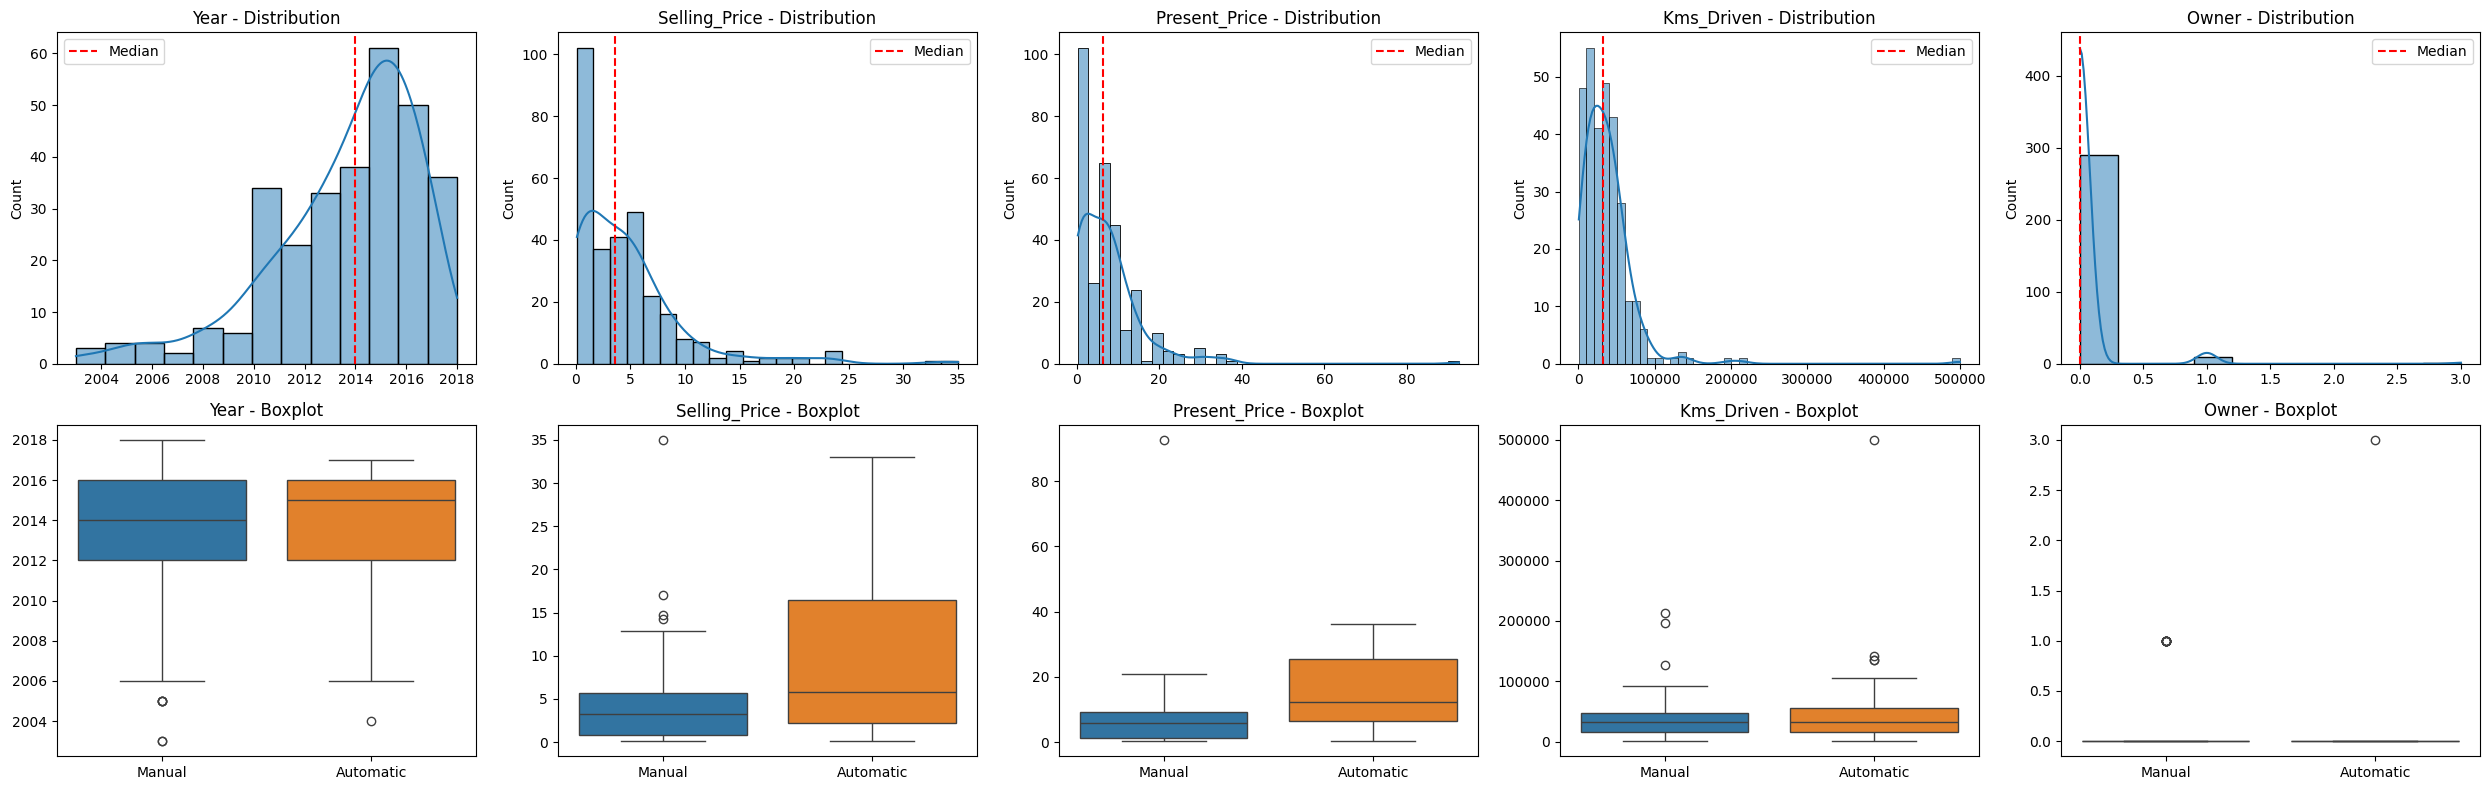

In [89]:
fig, ax = plt.subplots(2, len(num_cols), figsize=(5*len(num_cols), 8))

for i, col in enumerate(list(num_cols)):
  sns.histplot(data=df, x=col, ax=ax[0, i], kde=True)
  ax[0, i].axvline(df[col].median(), color="red", linestyle="--", label="Median")
  ax[0, i].legend()
  ax[0, i].set_title(f"{col} - Distribution")
  ax[0, i].set_xlabel(None)

  sns.boxplot(data=df, y=col, ax=ax[1, i], hue='Transmission', x='Transmission')
  ax[1, i].set_title(f"{col} - Boxplot")
  ax[1, i].set_xlabel(None)
  ax[1, i].set_ylabel(None)

plt.tight_layout()
plt.show()

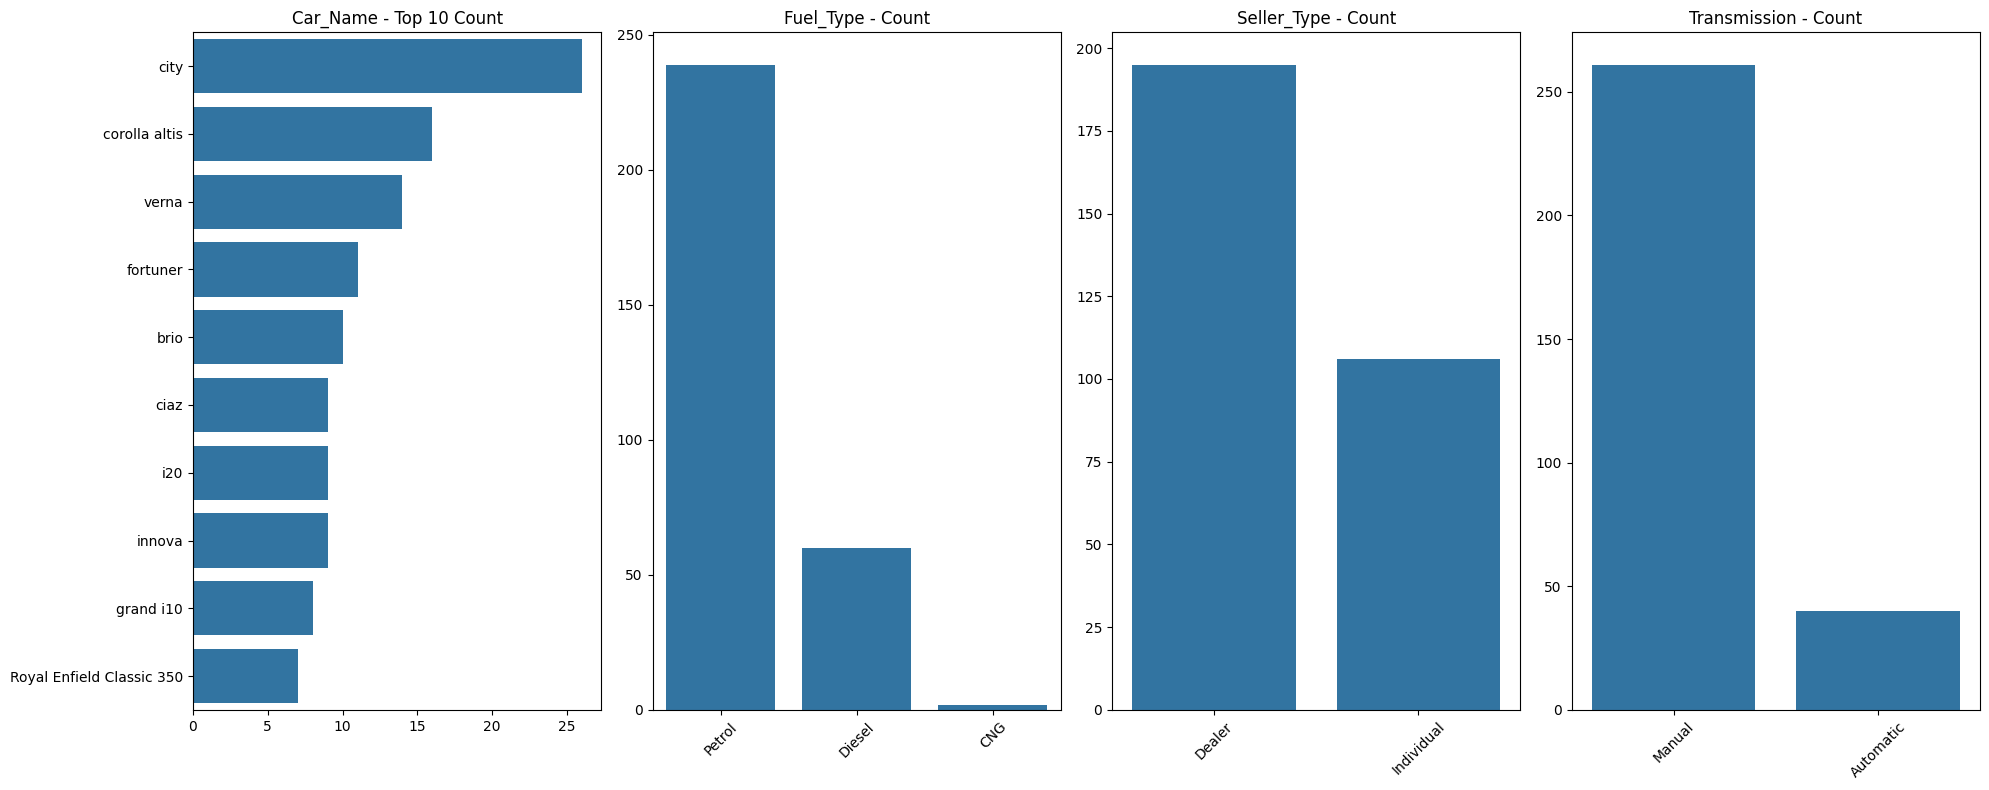

In [90]:
fig, ax = plt.subplots(1, len(cat_cols), figsize=(5*len(cat_cols), 8))

for i, col in enumerate(cat_cols):

    if df[col].nunique() > 10:
        top = df[col].value_counts().head(10)
        sns.barplot(x=top.values, y=top.index, ax=ax[i])
        ax[i].set_title(f"{col} - Top 10 Count")
        ax[i].set_xlabel(None)
        ax[i].set_ylabel(None)
    else:
        sns.countplot(data=df, x=col, ax=ax[i])
        ax[i].tick_params(axis='x', rotation=45)
        ax[i].set_title(f"{col} - Count")
        ax[i].set_xlabel(None)
        ax[i].set_ylabel(None)

plt.tight_layout()
plt.show()

## Pré Processamento dos Dados / Tratamento de Dados

In [91]:
datetime = datetime.datetime.now()
print(datetime)

2026-03-05 00:51:45.590671


In [92]:
datetime.year

2026

In [93]:
df.head(2)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0


In [94]:
df['Age'] = datetime.year - df['Year']

In [95]:
df.head(2)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13


In [96]:
df.drop('Year', axis=1, inplace=True)
df.head(2)

,Car_Name,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,13


In [97]:
df['Selling_Price'].sort_values(ascending=False)

,Selling_Price
86,35.00
64,33.00
63,23.50
51,23.00
93,23.00
82,23.00
96,20.75
59,19.99
66,19.75
62,18.75


In [98]:
df[(df['Selling_Price'] >= 30)]

,Car_Name,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
64,fortuner,33.0,36.23,6000,Diesel,Dealer,Automatic,0,9
86,land cruiser,35.0,92.60,78000,Diesel,Dealer,Manual,0,16


In [99]:
df[~(df['Selling_Price'] >= 30)]

,Car_Name,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,ritz,3.35,5.590,27000,Petrol,Dealer,Manual,0,12
1,sx4,4.75,9.540,43000,Diesel,Dealer,Manual,0,13
2,ciaz,7.25,9.850,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2.85,4.150,5200,Petrol,Dealer,Manual,0,15
4,swift,4.60,6.870,42450,Diesel,Dealer,Manual,0,12
5,vitara brezza,9.25,9.830,2071,Diesel,Dealer,Manual,0,8
6,ciaz,6.75,8.120,18796,Petrol,Dealer,Manual,0,11
7,s cross,6.50,8.610,33429,Diesel,Dealer,Manual,0,11
8,ciaz,8.75,8.890,20273,Diesel,Dealer,Manual,0,10
9,ciaz,7.45,8.920,42367,Diesel,Dealer,Manual,0,11


In [100]:
df = df[(df['Selling_Price'] < 30)]
df.shape

(299, 9)

In [101]:
df['Fuel_Type'].unique()

array(['Petrol', 'Diesel', 'CNG'], dtype=object)

In [102]:
df['Fuel_Type'] = df['Fuel_Type'].map({'Petrol':0, 'Diesel':1, 'CNG': 2})

df['Fuel_Type'].unique()

array([0, 1, 2])

In [103]:
df['Seller_Type'].unique()

array(['Dealer', 'Individual'], dtype=object)

In [104]:
df['Seller_Type'] = df['Seller_Type'].map({'Dealer':0, 'Individual':1})
df['Seller_Type'].unique()

array([0, 1])

In [105]:
df['Transmission'].unique()

array(['Manual', 'Automatic'], dtype=object)

In [106]:
df['Transmission'] = df['Transmission'].map({'Manual':0, 'Automatic':1})
df['Transmission'].unique()

array([0, 1])

In [107]:
X = df.drop(['Car_Name', 'Selling_Price'], axis=1) # variáveis preditoras
Y = df['Selling_Price'] # variável target

In [108]:
X.head()

,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,5.59,27000,0,0,0,0,12
1,9.54,43000,1,0,0,0,13
2,9.85,6900,0,0,0,0,9
3,4.15,5200,0,0,0,0,15
4,6.87,42450,1,0,0,0,12


In [109]:
Y.head()

,Selling_Price
0,3.35
1,4.75
2,7.25
3,2.85
4,4.60


## Separação dos Dados em Treino e Teste

In [110]:
X_Treino, X_Teste, Y_Treino, Y_Teste = train_test_split(X, Y, test_size = 0.25, random_state = 42)

In [111]:
print(X_Treino.shape)
print(X_Teste.shape)
print(Y_Treino.shape)
print(Y_Teste.shape)

(224, 7)
(75, 7)
(224,)
(75,)


In [112]:
X_Teste.head()

,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
283,11.80,9010,0,0,0,0,10
267,9.40,19434,1,0,0,0,10
166,0.55,1000,0,1,0,0,10
9,8.92,42367,1,0,0,0,11
78,22.83,80000,0,0,1,0,16


In [113]:
Y_Teste.head()

,Selling_Price
283,8.99
267,8.35
166,0.45
9,7.45
78,5.25


## Escolhendo algorítimos, criando e treinando o modelo

In [115]:
lr = LinearRegression()  # cria uma instância do modelo de regressão linear
lr.fit(X_Treino, Y_Treino)  # treina o modelo usando os dados de treino

rf = RandomForestRegressor()
rf.fit(X_Treino, Y_Treino)

xgb = GradientBoostingRegressor()
xgb.fit(X_Treino, Y_Treino)

xg = XGBRegressor()
xg.fit(X_Treino, Y_Treino)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [117]:
Previsoes_LR = lr.predict(X_Teste)
Previsoes_RF = rf.predict(X_Teste)
Previsoes_XGB = xgb.predict(X_Teste)
Previsoes_XG = xg.predict(X_Teste)

In [118]:
Previsoes_LR

array([ 8.28278028,  7.4327484 ,  1.34959496,  6.47486452, 12.47240402,
        4.42231142, 10.08337821,  1.78036592,  8.55652586, -1.2006253 ,
       11.70079826, -0.94663275, -0.14283369,  1.38549397,  9.83399181,
       10.91065926,  1.19275284,  1.990915  , 22.95723494,  0.76060948,
        0.86152762,  2.84299003,  5.67135223,  2.40639559,  2.40380555,
        8.84051307,  8.8347934 ,  1.18262436,  5.25541299,  5.13843666,
        7.85615747,  5.40967132,  6.74897474,  2.25202653,  8.35832457,
        6.44236986,  1.32559172, -8.76078087,  1.27903097, 11.71340266,
        8.05464548,  9.22587703,  1.68927992,  3.62952265,  0.93383064,
       -2.10894596,  9.11459453,  4.35185189,  4.68702363, -0.82262876,
        0.67575946,  0.20825226, 12.236819  ,  9.63226226,  8.24287125,
        5.50825999,  3.734612  ,  2.63625152,  9.91717564, 22.76908528,
        5.65875725, -0.34750726, -0.06260966, -0.89486744,  3.72114579,
        4.5256544 ,  8.66229626,  4.79182538,  2.53266326,  5.48

In [119]:
Previsoes_RF

array([ 9.9378,  8.241 ,  0.4463,  6.93  , 14.332 ,  5.226 ,  7.2746,
        1.168 ,  8.1092,  0.2989, 10.901 ,  0.2074,  0.2505,  0.4536,
        5.2334,  7.554 ,  0.6009,  1.1595, 21.833 ,  0.5464,  0.558 ,
        2.593 ,  6.23  ,  3.059 ,  2.4295,  9.266 ,  8.7145,  1.146 ,
        4.7952,  5.2756,  7.829 ,  4.407 ,  6.7125,  2.9635,  8.1996,
        6.3575,  1.1565,  0.1585,  1.1305, 13.9835,  6.9831,  9.0972,
        0.917 ,  3.4986,  0.568 ,  0.203 ,  9.8135,  4.963 ,  4.1255,
        0.209 ,  0.5948,  0.3392, 14.153 ,  9.9835,  7.7975,  6.65  ,
        3.268 ,  2.779 , 10.0655, 20.9755,  6.346 ,  0.3754,  0.2819,
        0.4114,  3.3125,  2.8745,  9.2181,  4.516 ,  2.831 ,  4.878 ,
        0.7748,  5.4483,  6.628 ,  8.4146,  0.4602])

In [120]:
Previsoes_XGB

array([ 9.00923343,  8.64896927,  0.50152715,  7.16937971, 10.45547848,
        4.83291485,  6.37124941,  1.27554532,  8.46867441,  0.49490727,
        9.08544057,  0.19053052,  0.30782999,  0.54581373,  5.52617437,
        7.22037598,  0.62297215,  1.46391008, 21.76817022,  0.43961997,
        0.51638347,  2.92659693,  5.89260292,  3.10835155,  2.5590835 ,
        8.94870628,  9.63589294,  1.06739498,  4.76331456,  4.92245168,
        7.79295931,  4.47415449,  6.7675291 ,  2.71437944,  7.87726067,
        6.49319491,  1.13851162,  0.10516101,  1.06575504,  8.74078233,
        7.08379176,  9.3238443 ,  0.9071901 ,  3.541864  ,  0.54255136,
        0.19814791,  9.71379649,  4.45087642,  3.99362443,  0.21202525,
        0.53981684,  0.31449198,  8.64897731, 11.17887495,  8.23131467,
        6.95056688,  3.4743416 ,  2.71338904, 13.08856829, 19.798471  ,
        6.73544895,  0.37526821,  0.27287853,  0.40597456,  3.47083873,
        3.08253492,  9.40532132,  4.46405796,  2.74326829,  4.68

In [121]:
Previsoes_XG

array([ 9.872594  ,  8.736616  ,  0.43426073,  7.0851126 , 10.577909  ,
        5.249046  ,  6.4713507 ,  1.2846173 ,  7.9020653 ,  0.28867725,
        9.350536  ,  0.23063433,  0.273173  ,  0.4327215 ,  4.9183073 ,
        7.168832  ,  0.63252544,  1.6783333 , 18.810719  ,  0.3639122 ,
        0.54363036,  1.3766756 ,  5.7287903 ,  2.9317951 ,  2.33132   ,
        9.133402  ,  8.74428   ,  1.0877929 ,  4.7220373 ,  5.1416407 ,
        7.759017  ,  3.9250464 ,  6.5938673 ,  2.3199859 ,  6.5538015 ,
        5.947032  ,  1.1404628 ,  0.15616448,  0.7267851 ,  8.725867  ,
        5.674859  ,  9.387238  ,  0.9283276 ,  3.7244139 ,  0.5020527 ,
        0.16577499, 10.2771    ,  4.6775894 ,  3.884433  ,  0.26816753,
        0.5585904 ,  0.372262  , 10.477427  , 10.528948  ,  5.862964  ,
        6.7667365 ,  3.394586  ,  2.7200377 , 11.598327  , 18.745384  ,
        6.307808  ,  0.26374128,  0.24767748,  0.39932987,  3.059431  ,
        2.9096043 ,  9.729754  ,  4.514561  ,  2.818545  ,  4.49

## Avaliando a Performance dos Algoritimos

In [123]:
score_LR = metrics.r2_score(Y_Teste, Previsoes_LR)
score_RF = metrics.r2_score(Y_Teste, Previsoes_RF)
score_XGB = metrics.r2_score(Y_Teste, Previsoes_XGB)
score_XG = metrics.r2_score(Y_Teste, Previsoes_XG)

In [128]:
modelos = [
    ('Linear Regression', score_LR),
    ('Random Forest', score_RF),
    ('XGBoost', score_XGB),
    ('XG Boost', score_XG)
]

for modelo, score in modelos:
  print(f"{modelo}: {score}")

Linear Regression: 0.7106971141598666
Random Forest: 0.7498130663925934
XGBoost: 0.9089718048314656
XG Boost: 0.8821570627049665


In [129]:
final_data = pd.DataFrame({'Models':['LR','RF','XGB', 'XG'], 'R2_Score': [score_LR, score_RF, score_XGB, score_XG]})
final_data

,Models,R2_Score
0,LR,0.710697
1,RF,0.749813
2,XGB,0.908972
3,XG,0.882157


## Melhorando a performance do Modelo com Normalização e Padronização

In [131]:
sc = MinMaxScaler()
X_treino_normalizados = sc.fit_transform(X_Treino)
X_teste_normalizados = sc.transform(X_Teste)

In [134]:
X_Treino.head()

,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
227,4.430,57000,0,0,0,0,15
79,30.610,89000,1,0,1,0,14
67,20.450,59000,1,0,0,0,16
298,11.000,87934,0,0,0,0,17
194,0.787,50000,0,1,0,0,18


In [132]:
X_treino_normalizados

array([[0.11531987, 0.26588235, 0.        , ..., 0.        , 0.        ,
        0.42857143],
       [0.84988777, 0.41647059, 0.5       , ..., 1.        , 0.        ,
        0.35714286],
       [0.56481481, 0.27529412, 0.5       , ..., 0.        , 0.        ,
        0.5       ],
       ...,
       [0.03310887, 0.08235294, 0.        , ..., 0.        , 0.        ,
        0.07142857],
       [0.27160494, 0.12752941, 0.        , ..., 0.        , 0.        ,
        0.14285714],
       [0.03226712, 0.01694118, 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [135]:
X_teste_normalizados

array([[ 3.22109989e-01,  4.00470588e-02,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         7.14285714e-02],
       [ 2.54769921e-01,  8.91011765e-02,  5.00000000e-01,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         7.14285714e-02],
       [ 6.45342312e-03,  2.35294118e-03,  0.00000000e+00,
         1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         7.14285714e-02],
       [ 2.41301908e-01,  1.97021176e-01,  5.00000000e-01,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.42857143e-01],
       [ 6.31593715e-01,  3.74117647e-01,  0.00000000e+00,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00,
         5.00000000e-01],
       [ 1.56565657e-01,  6.57176471e-02,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.42857143e-01],
       [ 5.13187430e-01,  3.36470588e-01,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         3.5714285

In [137]:
lr = LinearRegression()
lr.fit(X_treino_normalizados, Y_Treino)

rf = RandomForestRegressor()
rf.fit(X_treino_normalizados, Y_Treino)

xgb = GradientBoostingRegressor()
xgb.fit(X_treino_normalizados, Y_Treino)

xg = XGBRegressor()
xg.fit(X_treino_normalizados, Y_Treino)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [138]:
Previsoes_LR = lr.predict(X_teste_normalizados)
Previsoes_RF = rf.predict(X_teste_normalizados)
Previsoes_XGB = xgb.predict(X_teste_normalizados)
Previsoes_XG = xg.predict(X_teste_normalizados)

In [ ]:
#